# Pemodelan Sentimen Analisis Project

## Analisis Sentimen Ulasan Aplikasi DANA pada Google Play Store Menggunakan Support Vector Machine (SVM)

**Nama** : Nikita Ramanda

**NIM** : 092024090502

**Program Studi** : Teknik Informatika

**Mata Kuliah** : Artificial Intelligence

**Dosen Pengampu** : Anindya Ananda Hapsari, S.ST., MIT

# 1. Install Library

Pada tahap ini dilakukan instalasi library yang dibutuhkan untuk proses pengolahan data, preprocessing, ekstraksi fitur, pemodelan, dan evaluasi analisis sentimen.

In [1]:
!pip install Sastrawi
!pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.9 MB/s eta 0:00:00


# 2. Import Library

Tahap ini mengimpor seluruh library yang akan digunakan dalam proses analisis sentimen.

In [2]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import joblib

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# 3. Import Dataset

Pada tahap ini dataset hasil scraping diimpor ke dalam Google Colab untuk dilakukan proses analisis sentimen.

In [3]:
from google.colab import files

uploaded = files.upload()

Saving hasil_scraping_dana.csv to hasil_scraping_dana.csv


# 4. Menampilkan Dataset

Pada tahap ini dataset yang telah diimpor ditampilkan untuk memastikan data berhasil dimuat ke dalam Google Colab dan siap digunakan pada proses analisis sentimen.

In [4]:
# Membaca dataset hasil scraping

data = pd.read_csv('hasil_scraping_dana.csv')

# Menampilkan 5 data pertama

data.head()

,content,score,at
0,baguss,5,2026-06-28 12:46:27
1,Sangat bagus,5,2026-06-28 12:45:16
2,sangat bagus,5,2026-06-28 12:44:41
3,"cs kurang responsif, ga bisa menyelesaikan mas...",1,2026-06-28 12:42:45
4,sangat baik,5,2026-06-28 12:42:26


# 5. Informasi Dataset

Tahap ini bertujuan untuk mengetahui jumlah data, tipe data, serta memastikan tidak terdapat kesalahan pada struktur dataset.

In [5]:
# Menampilkan informasi dataset

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  2000 non-null   object
 1   score    2000 non-null   int64 
 2   at       2000 non-null   object
dtypes: int64(1), object(2)
memory usage: 47.0+ KB


In [6]:
# Menampilkan ukuran dataset

print("Jumlah Baris dan Kolom :", data.shape)

Jumlah Baris dan Kolom : (2000, 3)


# 6. Data Preprocessing

Tahap preprocessing dilakukan untuk membersihkan data teks agar lebih mudah diproses oleh algoritma machine learning.

## 6.1 Mengecek Missing Value

Tahap ini bertujuan untuk mengetahui apakah terdapat data yang kosong pada dataset.

In [7]:
# Mengecek missing value

data.isnull().sum()

,0
content,0
score,0
at,0


## 6.2 Menghapus Missing Value

Data yang kosong akan dihapus agar tidak mempengaruhi proses analisis sentimen.

In [8]:
# Menghapus data kosong

data = data.dropna()

print("Jumlah data setelah menghapus missing value :", len(data))

Jumlah data setelah menghapus missing value : 2000


## 6.3 Case Folding

Tahap ini bertujuan untuk mengubah seluruh huruf pada teks menjadi huruf kecil (lowercase) agar data menjadi lebih seragam dan memudahkan proses analisis.

In [9]:
# Mengubah seluruh teks menjadi huruf kecil

data['content'] = data['content'].str.lower()

data[['content']].head()

,content
0,baguss
1,sangat bagus
2,sangat bagus
3,"cs kurang responsif, ga bisa menyelesaikan mas..."
4,sangat baik


## 6.4 Cleaning Text

Tahap ini dilakukan untuk menghapus URL, mention, hashtag, angka, tanda baca, dan karakter yang tidak diperlukan agar teks menjadi lebih bersih.

In [10]:
import re
import string

def cleaning(text):
    text = re.sub(r'http\S+', '', text)          # Menghapus URL
    text = re.sub(r'@\w+', '', text)             # Menghapus mention
    text = re.sub(r'#\w+', '', text)             # Menghapus hashtag
    text = re.sub(r'\d+', '', text)              # Menghapus angka
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()
    return text

data['cleaning'] = data['content'].apply(cleaning)

data[['content', 'cleaning']].head()

,content,cleaning
0,baguss,baguss
1,sangat bagus,sangat bagus
2,sangat bagus,sangat bagus
3,"cs kurang responsif, ga bisa menyelesaikan mas...",cs kurang responsif ga bisa menyelesaikan masa...
4,sangat baik,sangat baik


## 6.5 Tokenizing

Tahap tokenizing dilakukan untuk memecah kalimat menjadi kumpulan kata.

In [11]:
data['tokenizing'] = data['cleaning'].apply(lambda x: x.split())

data[['cleaning', 'tokenizing']].head()

,cleaning,tokenizing
0,baguss,[baguss]
1,sangat bagus,"[sangat, bagus]"
2,sangat bagus,"[sangat, bagus]"
3,cs kurang responsif ga bisa menyelesaikan masa...,"[cs, kurang, responsif, ga, bisa, menyelesaika..."
4,sangat baik,"[sangat, baik]"


## 6.6 Stopword Removal

Tahap stopword removal dilakukan untuk menghapus kata-kata umum yang tidak memiliki makna penting dalam proses analisis sentimen, seperti "dan", "yang", "di", "ke", dan sebagainya.

In [12]:
# Mengunduh stopwords bahasa Indonesia
nltk.download('stopwords')

# Mengambil daftar stopwords
stop_words = set(stopwords.words('indonesian'))

# Menghapus stopwords
data['stopwords'] = data['tokenizing'].apply(
    lambda x: [word for word in x if word not in stop_words]
)

data[['tokenizing', 'stopwords']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,tokenizing,stopwords
0,[baguss],[baguss]
1,"[sangat, bagus]",[bagus]
2,"[sangat, bagus]",[bagus]
3,"[cs, kurang, responsif, ga, bisa, menyelesaika...","[cs, responsif, ga, menyelesaikan, udah, habis..."
4,"[sangat, baik]",[]


## 6.7 Stemming

Tahap stemming dilakukan untuk mengubah kata berimbuhan menjadi kata dasar menggunakan library Sastrawi.

In [14]:
# Membuat stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Proses stemming (lebih cepat)
data['stemming'] = data['stopwords'].apply(
    lambda x: stemmer.stem(' '.join(x))
)

data[['stopwords', 'stemming']].head()

,stopwords,stemming
0,[baguss],baguss
1,[bagus],bagus
2,[bagus],bagus
3,"[cs, responsif, ga, menyelesaikan, udah, habis...",cs responsif ga selesai udah habis pulsa rb tl...
4,[],


## 6.8 Menggabungkan Hasil Stemming

Tahap ini menggabungkan hasil stemming menjadi sebuah kalimat yang akan digunakan pada proses ekstraksi fitur menggunakan TF-IDF.

In [15]:
data['processed_text'] = data['stemming']

data[['processed_text']].head()

,processed_text
0,baguss
1,bagus
2,bagus
3,cs responsif ga selesai udah habis pulsa rb tl...
4,


# 7. Pelabelan Sentimen

Tahap ini dilakukan untuk memberikan label sentimen berdasarkan nilai rating yang diberikan oleh pengguna. Label sentimen akan digunakan sebagai target pada proses klasifikasi menggunakan algoritma Support Vector Machine (SVM).

In [16]:
# Fungsi pelabelan sentimen berdasarkan rating

def label_sentimen(score):
    if score <= 2:
        return "Negatif"
    elif score == 3:
        return "Netral"
    else:
        return "Positif"

# Menambahkan kolom sentimen
data['sentimen'] = data['score'].apply(label_sentimen)

# Menampilkan hasil
data[['score', 'sentimen']].head()

,score,sentimen
0,5,Positif
1,5,Positif
2,5,Positif
3,1,Negatif
4,5,Positif


In [17]:
# Distribusi label sentimen

data['sentimen'].value_counts()

,count
sentimen,
Positif,1352
Negatif,556
Netral,92


# 8. Ekstraksi Fitur TF-IDF

Tahap ini mengubah data teks hasil preprocessing menjadi bentuk numerik menggunakan metode Term Frequency-Inverse Document Frequency (TF-IDF), sehingga dapat diproses oleh algoritma Support Vector Machine (SVM).

In [18]:
# Membuat objek TF-IDF

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(data['processed_text'])

y = data['sentimen']

print("Ukuran TF-IDF :", X.shape)

Ukuran TF-IDF : (2000, 2161)


# 9. Pembagian Data Training dan Testing

Pada tahap ini dataset dibagi menjadi data training dan data testing. Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk menguji performa model.

In [19]:
# Membagi data menjadi data training dan testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Jumlah Data Training :", X_train.shape[0])
print("Jumlah Data Testing  :", X_test.shape[0])

Jumlah Data Training : 1600
Jumlah Data Testing  : 400


# 10. Pemodelan Support Vector Machine (SVM)

Tahap ini dilakukan untuk melatih model klasifikasi sentimen menggunakan algoritma Support Vector Machine (SVM) berdasarkan data training.

In [20]:
# Membuat dan melatih model SVM

model = SVC(kernel='linear')

model.fit(X_train, y_train)

print("Model SVM berhasil dilatih.")

Model SVM berhasil dilatih.


# 11. Evaluasi Model

Tahap ini dilakukan untuk mengetahui performa model menggunakan data testing.

In [21]:
# Melakukan prediksi

y_pred = model.predict(X_test)

In [22]:
# Menghitung akurasi model

accuracy = accuracy_score(y_test, y_pred)

print("Akurasi Model :", accuracy)

Akurasi Model : 0.8475


In [23]:
# Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Negatif       0.81      0.73      0.77       112
      Netral       0.00      0.00      0.00        18
     Positif       0.86      0.95      0.90       270

    accuracy                           0.85       400
   macro avg       0.56      0.56      0.56       400
weighted avg       0.81      0.85      0.83       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [24]:
# Confusion Matrix

confusion_matrix(y_test, y_pred)

array([[ 82,   0,  30],
       [  6,   0,  12],
       [ 13,   0, 257]])

# 12. Menyimpan Model

Tahap ini menyimpan model SVM dan TF-IDF Vectorizer agar dapat digunakan kembali pada proses pengujian tanpa perlu melakukan pelatihan ulang.

In [26]:
# Menyimpan model dan TF-IDF

joblib.dump(model, 'svm_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("Model dan TF-IDF berhasil disimpan.")

Model dan TF-IDF berhasil disimpan.


# 13. Visualisasi Hasil

## 13.1 Diagram Batang Distribusi Sentimen

Diagram batang digunakan untuk menampilkan jumlah data pada masing-masing kelas sentimen.

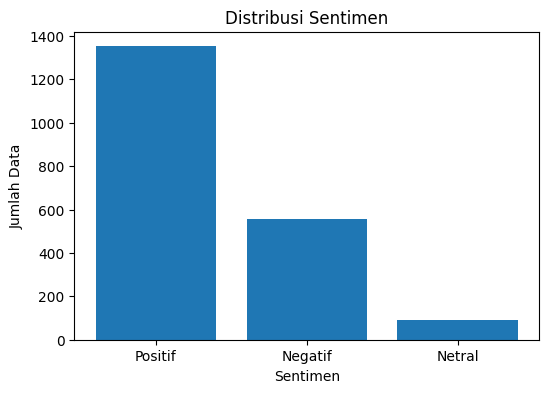

In [27]:
import matplotlib.pyplot as plt

sentiment_count = data['sentimen'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(sentiment_count.index, sentiment_count.values)

plt.title("Distribusi Sentimen")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Data")

plt.show()

## 13.2 Diagram Lingkaran Distribusi Sentimen

Diagram lingkaran digunakan untuk menunjukkan persentase masing-masing kategori sentimen.

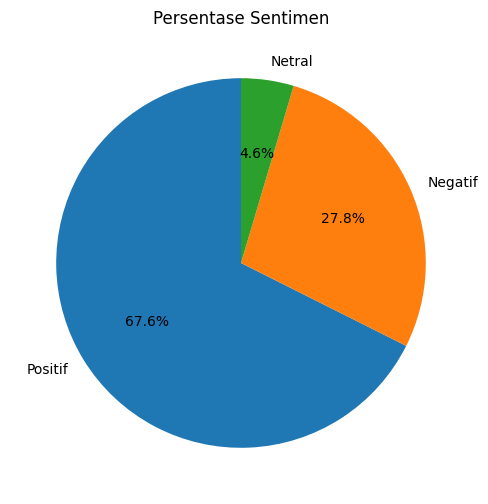

In [28]:
plt.figure(figsize=(6,6))

plt.pie(
    sentiment_count.values,
    labels=sentiment_count.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Persentase Sentimen")

plt.show()

In [29]:
from wordcloud import WordCloud

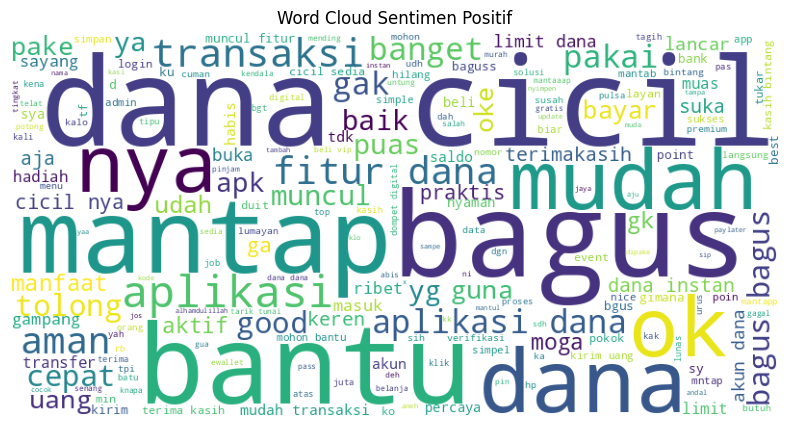

In [30]:
positive = ' '.join(
    data[data['sentimen']=='Positif']['processed_text']
)

wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")
plt.title("Word Cloud Sentimen Positif")
plt.show()

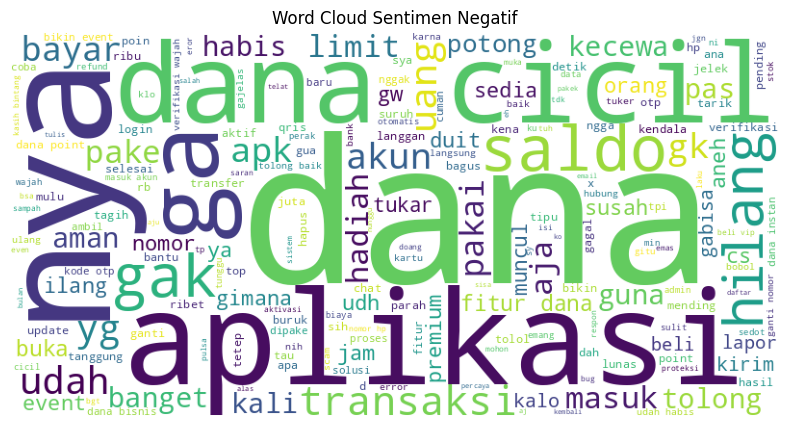

In [31]:
negative = ' '.join(
    data[data['sentimen']=='Negatif']['processed_text']
)

wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")
plt.title("Word Cloud Sentimen Negatif")
plt.show()

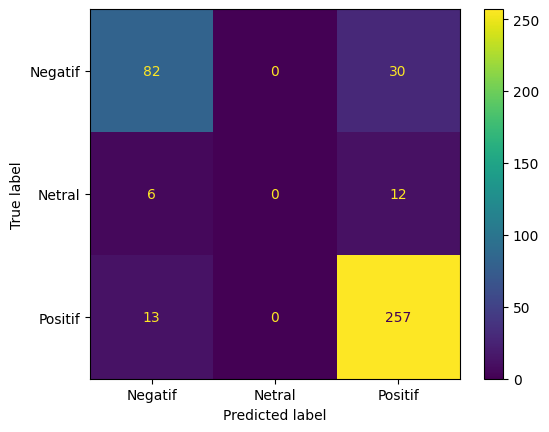

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test
)

plt.show()